## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
MONTH = 'July'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-07-01,2023,7,2023-06-29,37.991999,23.654887,0.084740,-0.047921,-0.158146,0.047921,0.118823,-0.046635,-0.181876,0.046635,0.036749,0.011726,0.028526,0.011726,2023-06-28,37.991999,23.654887,15632.0,14953.0,37.991999,23.654887,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,2023-07-01,37.950174,23.650108,348.910701,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.000000,7.175271e-07
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-07-01,2023,7,2023-06-29,38.009965,23.825567,0.221898,0.039122,-0.252935,-0.039122,0.225325,0.041237,-0.251772,-0.041237,0.027407,0.016003,0.019940,0.016003,2023-06-28,38.009965,23.825567,15544.0,14935.0,38.009965,23.825567,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,2023-07-01,38.050174,23.850109,425.951674,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.230000,2.300007e-01
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-07-01,2023,7,2023-06-29,37.933609,23.731244,0.144524,-0.017447,-0.205789,0.017447,0.121626,-0.024938,-0.185078,0.024938,0.022787,0.008053,0.018208,0.008053,2023-06-28,37.933609,23.731244,15533.0,14997.0,37.933609,23.731244,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,2023-07-01,37.950174,23.750109,365.646401,2023-06-24,2023-06-17,2023-06-24,2023-06-17,1.260796,1.260797e+00
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-07-01,2023,7,2023-06-29,38.045898,23.713278,0.174729,-0.037581,-0.218953,0.037581,0.202208,-0.045446,-0.242367,0.045446,0.038159,0.018299,0.025526,0.018299,2023-06-28,38.045898,23.713278,15647.0,14925.0,38.045898,23.713278,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,2023-07-01,38.050174,23.750109,437.278102,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.700796,7.007964e-01
4,αγκιστριου,αττικης,23.34009,37.69503,2023-07-01,2023,7,2023-06-29,37.695555,23.340477,0.331972,-0.008209,-0.258002,0.008209,0.326338,-0.030557,-0.266957,0.030557,0.028594,0.055318,0.012242,0.055318,2023-06-28,37.695555,23.340477,15282.0,14927.0,37.695555,23.340477,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,2023-07-01,37.650172,23.350107,485.607311,2023-06-24,2023-06-17,2023-06-24,2023-06-17,2.460000,2.460000e+00


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-07-01,2023,7,0.084740,-0.047921,-0.158146,0.047921,0.118823,-0.046635,-0.181876,0.046635,0.036749,0.011726,0.028526,0.011726,15632.0,14953.0,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.000000,7.175271e-07
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-07-01,2023,7,0.221898,0.039122,-0.252935,-0.039122,0.225325,0.041237,-0.251772,-0.041237,0.027407,0.016003,0.019940,0.016003,15544.0,14935.0,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.230000,2.300007e-01
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-07-01,2023,7,0.144524,-0.017447,-0.205789,0.017447,0.121626,-0.024938,-0.185078,0.024938,0.022787,0.008053,0.018208,0.008053,15533.0,14997.0,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,1.260796,1.260797e+00
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-07-01,2023,7,0.174729,-0.037581,-0.218953,0.037581,0.202208,-0.045446,-0.242367,0.045446,0.038159,0.018299,0.025526,0.018299,15647.0,14925.0,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.700796,7.007964e-01
4,αγκιστριου,αττικης,23.34009,37.69503,2023-07-01,2023,7,0.331972,-0.008209,-0.258002,0.008209,0.326338,-0.030557,-0.266957,0.030557,0.028594,0.055318,0.012242,0.055318,15282.0,14927.0,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607311,2.460000,2.460000e+00


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2023.0,7.0,0.084740,-0.047921,-0.158146,0.047921,0.118823,-0.046635,-0.181876,0.046635,0.036749,0.011726,0.028526,0.011726,15632.000000,14953.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.000000,7.175271e-07
1,2023-07-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2023.0,7.0,0.221898,0.039122,-0.252935,-0.039122,0.225325,0.041237,-0.251772,-0.041237,0.027407,0.016003,0.019940,0.016003,15544.000000,14935.000000,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.230000,2.300007e-01
2,2023-07-01,αγιου δημητριου,αττικης,23.730310,37.933570,2023.0,7.0,0.144524,-0.017447,-0.205789,0.017447,0.121626,-0.024938,-0.185078,0.024938,0.022787,0.008053,0.018208,0.008053,15533.000000,14997.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,1.260796,1.260797e+00
3,2023-07-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2023.0,7.0,0.174729,-0.037581,-0.218953,0.037581,0.202208,-0.045446,-0.242367,0.045446,0.038159,0.018299,0.025526,0.018299,15647.000000,14925.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.700796,7.007964e-01
4,2023-07-01,αγκιστριου,αττικης,23.340090,37.695030,2023.0,7.0,0.331972,-0.008209,-0.258002,0.008209,0.326338,-0.030557,-0.266957,0.030557,0.028594,0.055318,0.012242,0.055318,15282.000000,14927.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607311,2.460000,2.460000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-07-01,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2023.0,7.0,0.294598,0.052593,-0.304666,-0.052593,0.269272,0.042526,-0.289066,-0.042526,0.028611,0.023384,0.020924,0.023384,15590.000000,14918.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,437.278102,0.700796,7.007964e-01
62,2023-07-01,φυλης,αττικης,23.688620,38.106703,2023.0,7.0,0.302347,-0.008177,-0.310261,0.008177,0.343635,0.010824,-0.330390,-0.010824,0.044973,0.039287,0.023219,0.039287,15429.666667,14749.666667,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,400.114421,0.173070,1.730708e-01
63,2023-07-01,χαλανδριου,αττικης,23.809410,38.022260,2023.0,7.0,0.241283,0.047587,-0.269098,-0.047587,0.251064,0.048081,-0.274826,-0.048081,0.049997,0.031831,0.035210,0.031831,15595.000000,14948.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,425.951674,0.230000,2.300007e-01
64,2023-07-01,χαϊδαριου,αττικης,23.630840,38.009420,2023.0,7.0,0.329143,-0.054143,-0.305393,0.054143,0.326633,-0.030296,-0.300655,0.030296,0.036025,0.032634,0.018176,0.032634,15565.000000,14886.000000,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,439.846210,0.519211,5.192121e-01


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

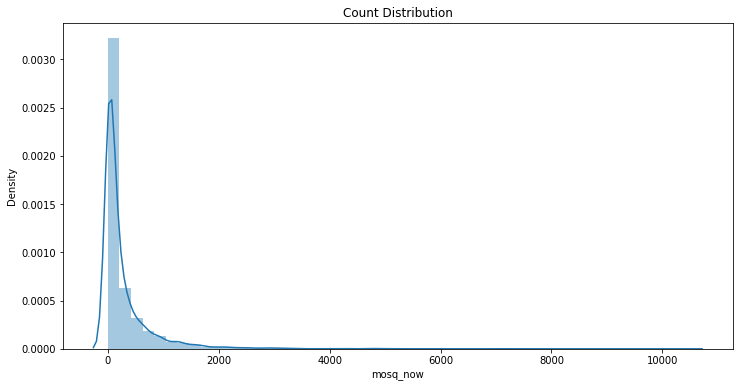

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

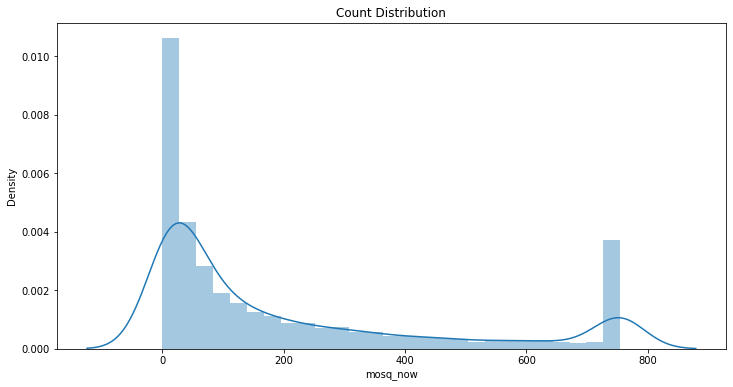

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

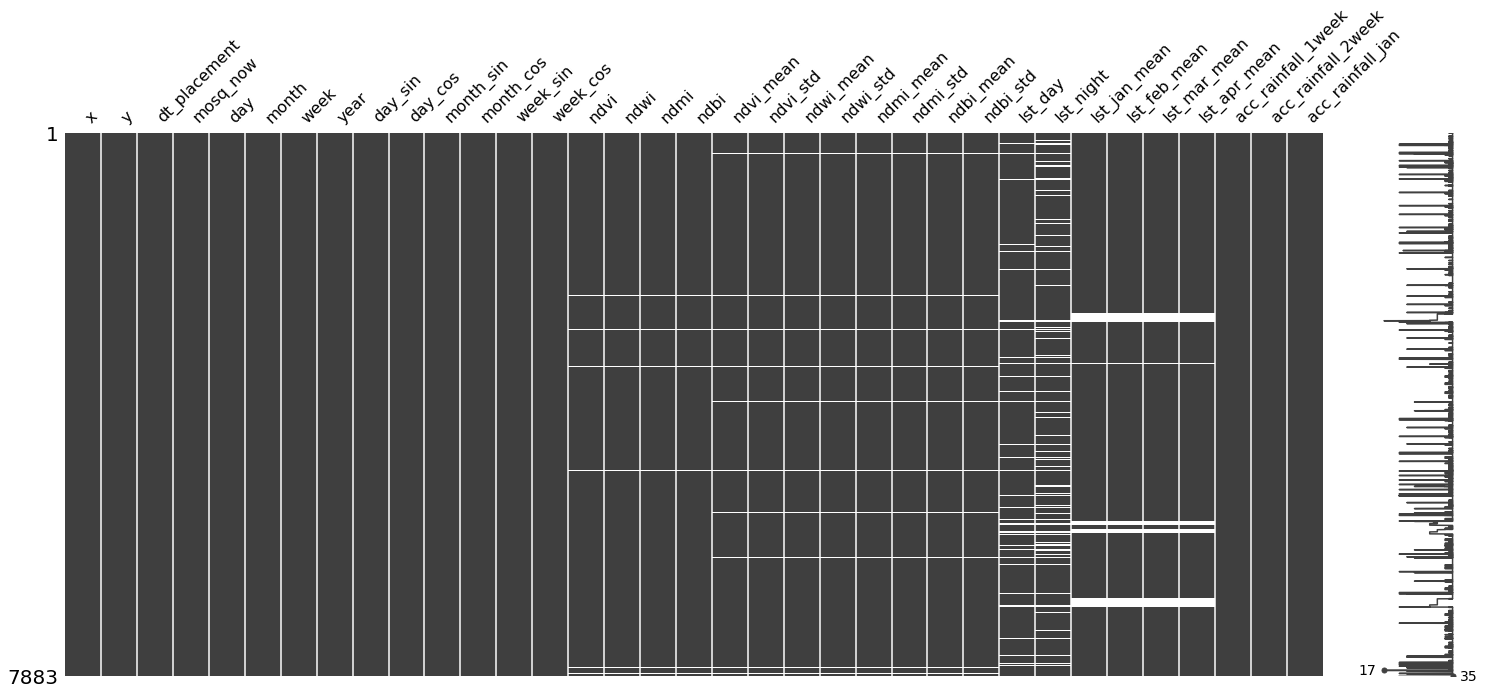

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

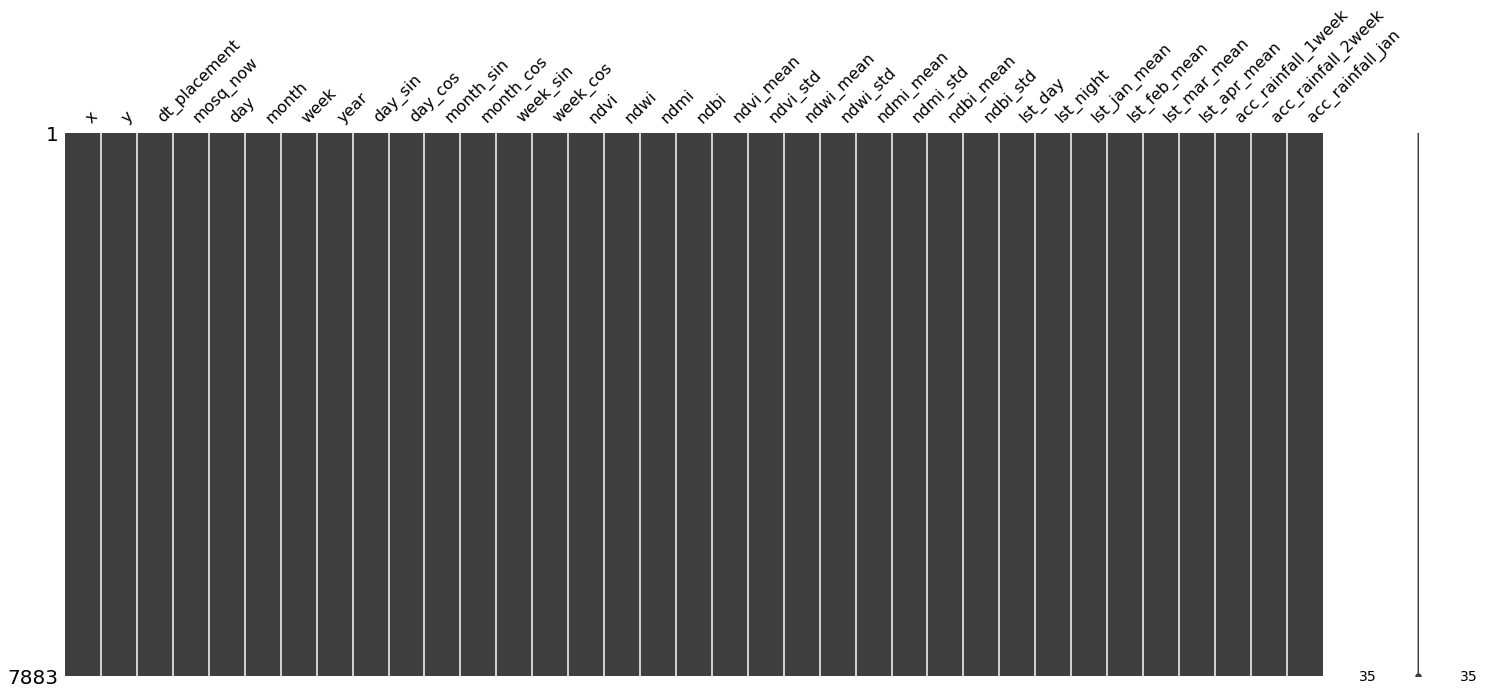

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.61420 | Val Loss: 23.61256 | Train Acc: 2.653| Val Acc: 1.972
Epoch 002: | Train Loss: 18.65458 | Val Loss: 25.49475 | Train Acc: 2.267| Val Acc: 2.035
Epoch 003: | Train Loss: 18.26861 | Val Loss: 25.38752 | Train Acc: 2.181| Val Acc: 2.033
Epoch 004: | Train Loss: 18.06161 | Val Loss: 24.35981 | Train Acc: 2.119| Val Acc: 1.944
Epoch 005: | Train Loss: 17.72994 | Val Loss: 24.37966 | Train Acc: 2.081| Val Acc: 1.929
Epoch 006: | Train Loss: 17.36383 | Val Loss: 24.47465 | Train Acc: 2.006| Val Acc: 1.974
Epoch 007: | Train Loss: 17.24695 | Val Loss: 24.05667 | Train Acc: 2.005| Val Acc: 1.978
Epoch 008: | Train Loss: 16.84635 | Val Loss: 24.40219 | Train Acc: 1.982| Val Acc: 1.968
Epoch 009: | Train Loss: 16.75243 | Val Loss: 24.40053 | Train Acc: 1.981| Val Acc: 2.012
Epoch 010: | Train Loss: 16.70251 | Val Loss: 24.77318 | Train Acc: 1.996| Val Acc: 2.054
Epoch 011: | Train Loss: 16.68028 | Val Loss: 24.35166 | Train Acc: 1.988| Val Acc: 2.068
Epoch 012:

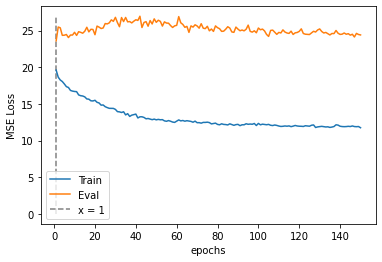

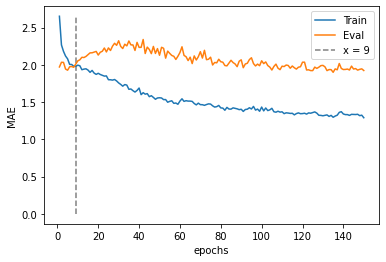

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  147.8975273885794
min prediction: 1
max prediction: 1721

MAE on test set:  151.03840245677654
Error ⩽ 30: 20.57 %
min prediction: 1
max prediction: 962


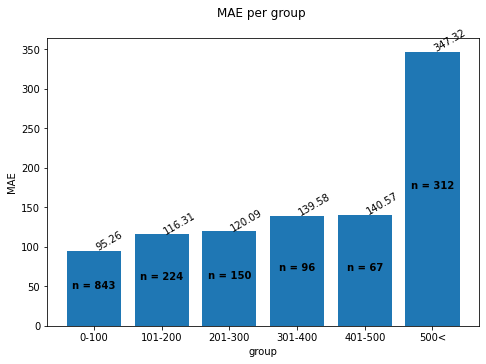

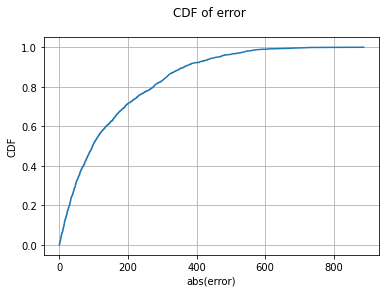

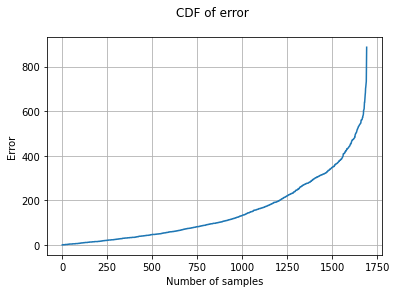

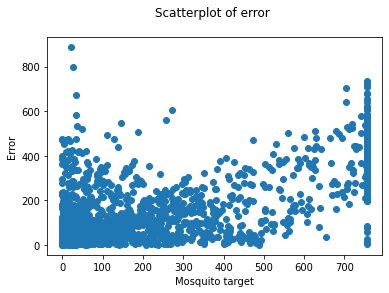

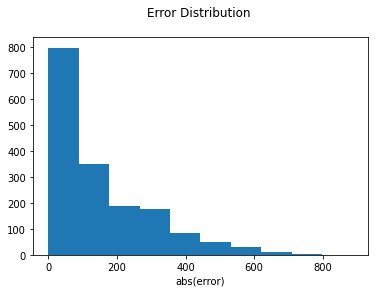

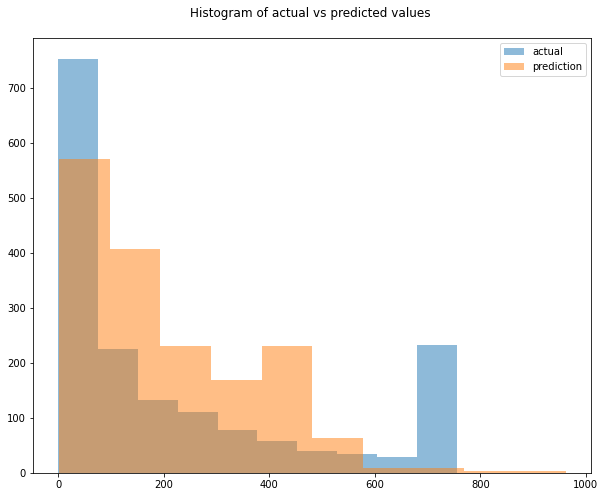

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.48323 | Val Loss: 3.56162 | Train Acc: 1.533| Val Acc: 1.633
Epoch 002: | Train Loss: 13.36758 | Val Loss: 3.75973 | Train Acc: 1.520| Val Acc: 1.633
Epoch 003: | Train Loss: 13.25829 | Val Loss: 3.14736 | Train Acc: 1.493| Val Acc: 1.633
Epoch 004: | Train Loss: 13.31367 | Val Loss: 2.84264 | Train Acc: 1.492| Val Acc: 1.633
Epoch 005: | Train Loss: 13.03886 | Val Loss: 4.00344 | Train Acc: 1.476| Val Acc: 1.633
Epoch 006: | Train Loss: 13.03116 | Val Loss: 4.83647 | Train Acc: 1.478| Val Acc: 2.633
Epoch 007: | Train Loss: 13.01339 | Val Loss: 5.95018 | Train Acc: 1.457| Val Acc: 2.633
Epoch 008: | Train Loss: 12.96553 | Val Loss: 4.51944 | Train Acc: 1.457| Val Acc: 1.633
Epoch 009: | Train Loss: 12.85483 | Val Loss: 4.36398 | Train Acc: 1.445| Val Acc: 1.633
Epoch 010: | Train Loss: 12.82654 | Val Loss: 5.78358 | Train Acc: 1.440| Val Acc: 2.633
Epoch 011: | Train Loss: 12.80517 | Val Loss: 5.91723 | Train Acc: 1.441| Val Acc: 2.633
Epoch 012: | Train Lo

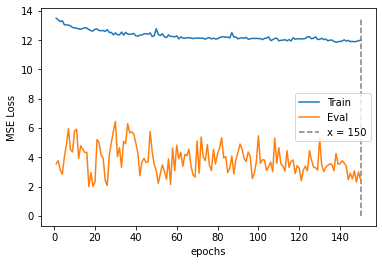

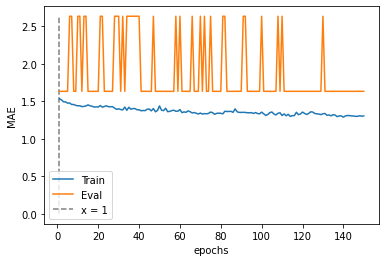

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

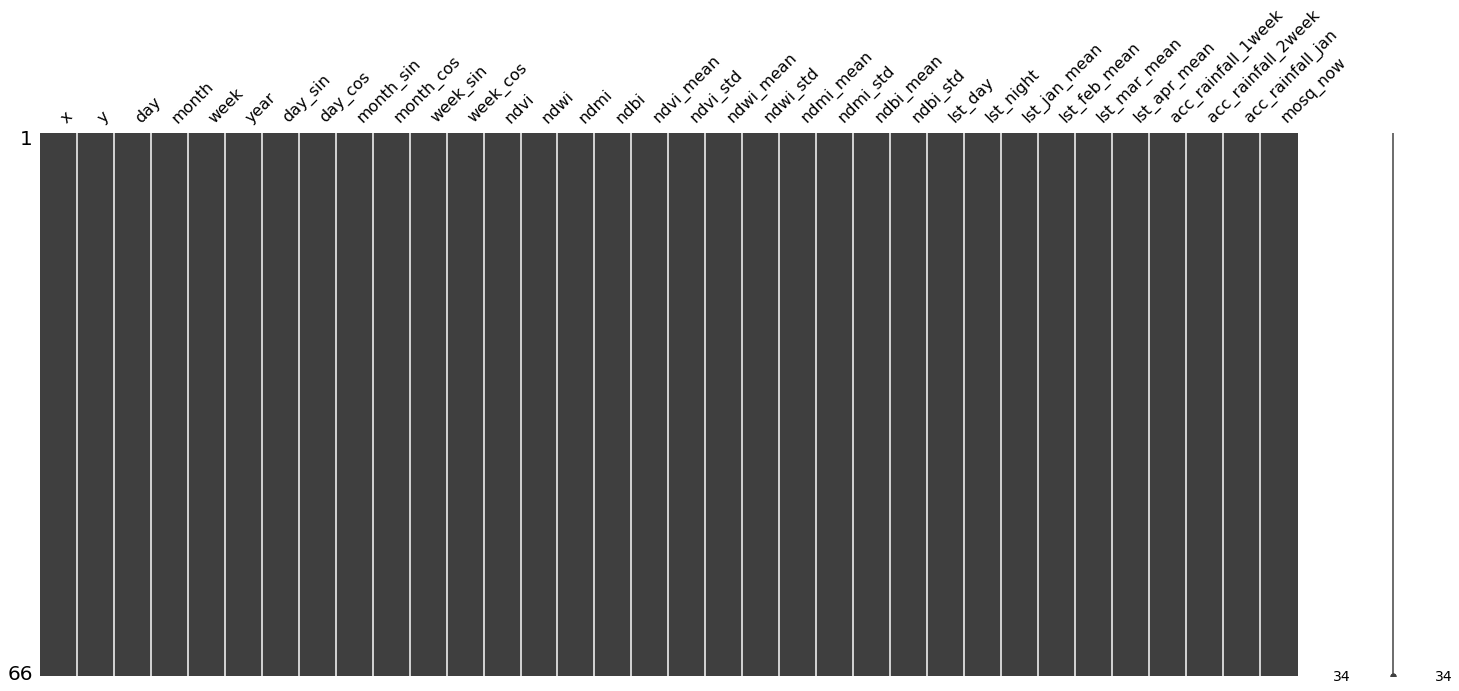

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [45]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2023-07-01,422
1,23.826420,38.008060,2023-07-01,148
2,23.730310,37.933570,2023-07-01,273
3,23.713410,38.047210,2023-07-01,198
4,23.340090,37.695030,2023-07-01,93
...,...,...,...,...
61,23.776280,38.014770,2023-07-01,124
62,23.688620,38.106703,2023-07-01,164
63,23.809410,38.022260,2023-07-01,120
64,23.630840,38.009420,2023-07-01,112


In [46]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-{MONTH}-{PERIOD}.csv', index = False)